#**Introduction**#

Customer segmentation is a key technique used in business to group customers based on similar behaviors, such as purchase history. In this project, we aim to cluster customers using unsupervised learning techniques — specifically **K-Means Clustering** and **Hierarchical Clustering**.

These techniques help identify patterns in customer behavior which businesses can leverage to tailor marketing strategies, improve customer satisfaction, and increase profits.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import mlxtend

###**Step1: Loading The Dataset**

In [ ]:
df = pd.read_csv('/content/data.csv', encoding='latin-1')

###**Step2: Exploratary Data Analysis**###

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,12/9/2011 12:50,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,12/9/2011 12:50,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,12/9/2011 12:50,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,12/9/2011 12:50,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/2011 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


From the above analysis we can predict that the columns customerID and Description have null values that needs to be treated

In [ ]:
#getting statistical summary for numerical varaiables
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.describe(include='object')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


we can infer from the above data that

*   the negative value in quantity refers to cancelled order. there is also a possibility of outliers due to large difference between 75th percentile and maximum value of data. the high standard deviation also indicates wide spread of data
*   for unit price the presence of outliers can be seen due to the difference between 75tth percentile and maximum value
*   there are 8072 unique invoice numbers indicating 8072 unique transactions, and the most frequent invoice number is 537434 appearing 675 time
*   there are 3344 unique stock items that have been sold, and the most frequent one from them is 85123A apearing 890 times
*   there are some missing values in the description column that needs to be treated










###**Step3: DATA CLEANING AND TRANSFORMATION**###

####Handling Null Values

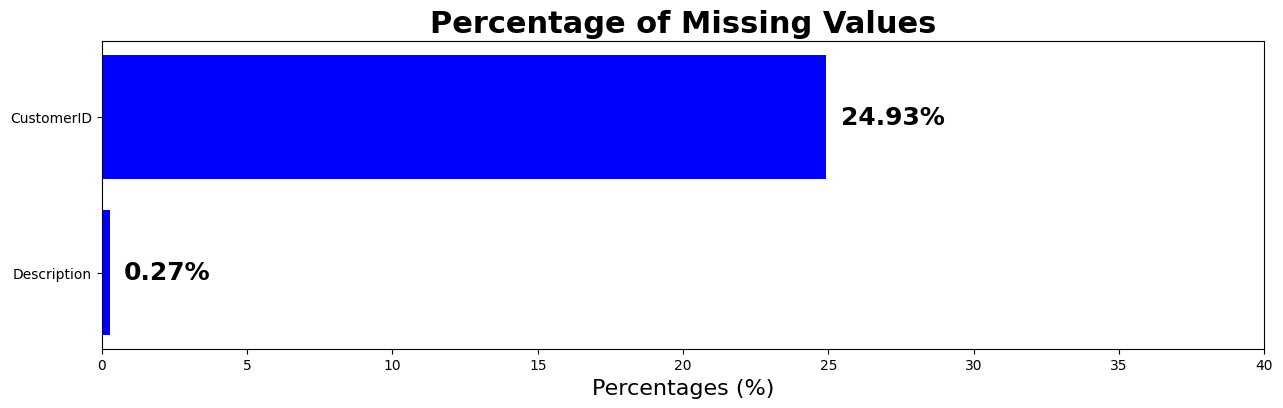

In [ ]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data[missing_data > 0] /df.shape[0]) * 100
missing_percentage.sort_values(ascending=True, inplace=True)

fig,ax = plt.subplots(figsize = (15,4))
ax.barh(missing_percentage.index, missing_percentage, color='blue')

for i, (value, name) in enumerate(zip(missing_percentage, missing_percentage.index)):
    ax.text(value+0.5, i, f"{value:.2f}%", ha='left', va='center', fontweight='bold', fontsize=18, color='black')

# Set x-axis limit
ax.set_xlim([0, 40])

# Add title and xlabel
plt.title("Percentage of Missing Values", fontweight='bold', fontsize=22)
plt.xlabel('Percentages (%)', fontsize=16)
plt.show()

customer ID has 24.93% missing values which is almost one quarter of the dataset so these values need to be handled. the column is also essential for clustering customers, such a large portion of null values can cause noise in the data.
Description column has 0.27% null values however there is a descripency in the data that usually the same stock code doesn't have the same description which neeeds to be sorted

In [ ]:
df[df['CustomerID'].isnull() | df['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [ ]:
df = df.dropna(subset=['CustomerID','Description'])

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


####Handling Duplicate Values

In [ ]:
#finding duplicate rows keeping all instances
duplicate_rows = df[df.duplicated(keep=False)]

# Sorting the data by certain columns to see the duplicate rows next to each other
duplicate_rows_sorted = duplicate_rows.sort_values(by=['InvoiceNo', 'StockCode', 'Description', 'CustomerID', 'Quantity'])

# Displaying the first 10 records
duplicate_rows_sorted.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [ ]:
print('the total no of duplicates to be removed is',df.duplicated().sum())
df.drop_duplicates(inplace=True)

the total no of duplicates to be removed is 5225


In [ ]:
df.shape

(401604, 8)

####Cancelled Transactions

In [ ]:
# Filter out the rows with InvoiceNo starting with "C" and create a new column indicating the transaction status
df['Transaction_Status'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Completed')

cancelled_transactions = df[df['Transaction_Status'] == 'Cancelled']
cancelled_transactions.describe().drop('CustomerID', axis=1)

,Quantity,UnitPrice
count,8872.000000,8872.000000
mean,-30.774910,18.899512
std,1172.249902,445.190864
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,4.950000
max,-1.000000,38970.000000


####Handling StockCode Anomaly

In [ ]:
# Finding the number of unique stock codes
unique_stock_codes = df['StockCode'].nunique()

# Printing the number of unique stock codes
print(f"The number of unique stock codes in the dataset is: {unique_stock_codes}")

The number of unique stock codes in the dataset is: 3684


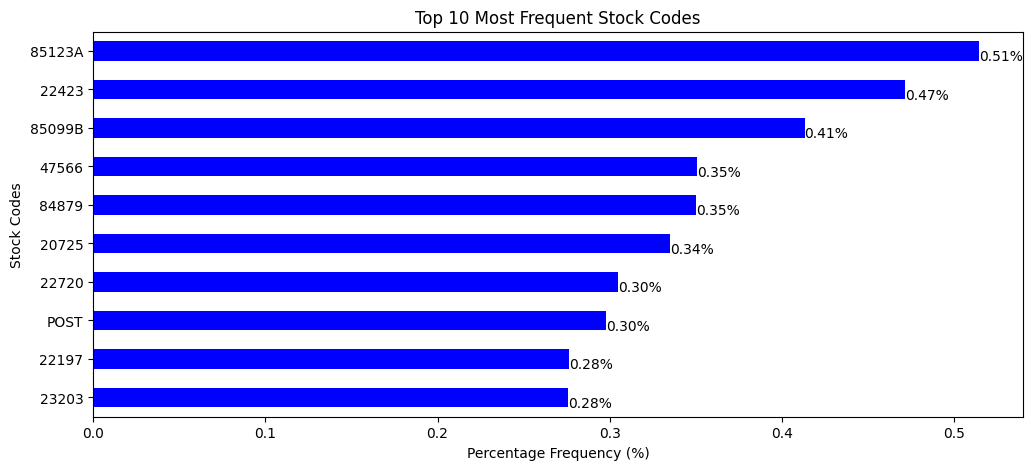

In [ ]:
# Finding the top 10 most frequent stock codes
top_10_stock_codes = df['StockCode'].value_counts(normalize=True).head(10) * 100

# Plotting the top 10 most frequent stock codes
plt.figure(figsize=(12, 5))
top_10_stock_codes.plot(kind='barh', color='blue')

# Adding the percentage frequency on the bars
for index, value in enumerate(top_10_stock_codes):
    plt.text(value, index+0.25, f'{value:.2f}%', fontsize=10)

plt.title('Top 10 Most Frequent Stock Codes')
plt.xlabel('Percentage Frequency (%)')
plt.ylabel('Stock Codes')
plt.gca().invert_yaxis()
plt.show()

Inferences on Stock Codes

Product Variety: The dataset contains 3684 unique stock codes, indicating a
substantial variety of products available in the online retail store. This diversity can potentially lead to the identification of distinct customer clusters, with preferences for different types of products.

Popular Items: A closer look at the top 10 most frequent stock codes can offer insights into the popular products or categories that are frequently purchased by customers.

Stock Code Anomalies: We observe that while most stock codes are composed of 5 or 6 characters, there are some anomalies like the code 'POST'. These anomalies might represent services or non-product transactions (perhaps postage fees) rather than actual products. To maintain the focus of the project, which is clustering based on product purchases and creating a recommendation system, these anomalies should be further investigated and possibly treated appropriately to ensure data integrity.

In [ ]:
# Finding the number of numeric characters in each unique stock code
unique_stock_codes = df['StockCode'].unique()
numeric_char_counts_in_unique_codes = pd.Series(unique_stock_codes).apply(lambda x: sum(c.isdigit() for c in str(x))).value_counts()

# Printing the value counts for unique stock codes
print("Value counts of numeric character frequencies in unique stock codes:")
print("-"*70)
print(numeric_char_counts_in_unique_codes)

Value counts of numeric character frequencies in unique stock codes:
----------------------------------------------------------------------
5    3676
0       7
1       1
Name: count, dtype: int64


In [ ]:
# Finding and printing the stock codes with 0 and 1 numeric characters
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

# Printing each stock code on a new line
print("Anomalous stock codes:")
print("-"*22)
for code in anomalous_stock_codes:
    print(code)

Anomalous stock codes:
----------------------
POST
D
C2
M
BANK CHARGES
PADS
DOT
CRUK


In [ ]:
# Calculating the percentage of records with these stock codes
percentage_anomalous = (df['StockCode'].isin(anomalous_stock_codes).sum() / len(df)) * 100

# Printing the percentage
print(f"The percentage of records with anomalous stock codes in the dataset is: {percentage_anomalous:.2f}%")

The percentage of records with anomalous stock codes in the dataset is: 0.48%


In [ ]:
# Removing rows with anomalous stock codes from the dataset
df = df[~df['StockCode'].isin(anomalous_stock_codes)]

In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

399689

####Cleaning Description Column

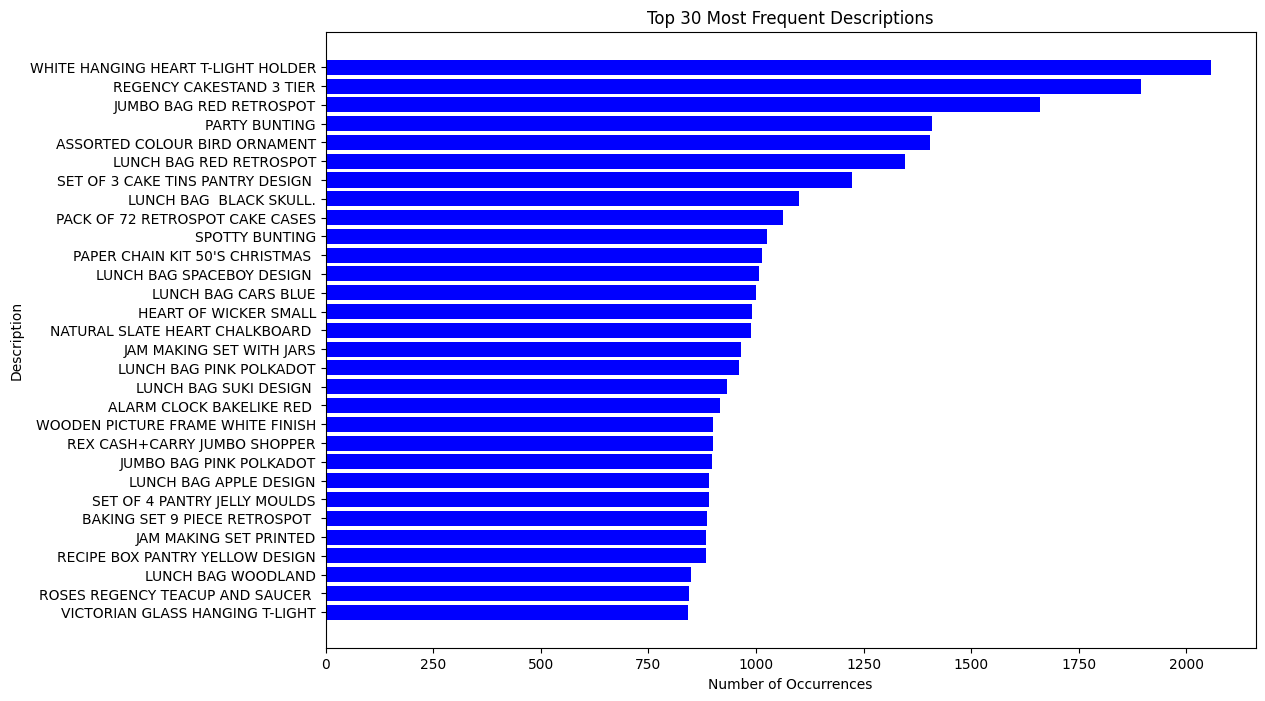

In [ ]:
# Calculate the occurrence of each unique description and sort them
description_counts = df['Description'].value_counts()

# Get the top 30 descriptions
top_30_descriptions = description_counts[:30]

# Plotting
plt.figure(figsize=(12,8))
plt.barh(top_30_descriptions.index[::-1], top_30_descriptions.values[::-1], color='blue')

# Adding labels and title
plt.xlabel('Number of Occurrences')
plt.ylabel('Description')
plt.title('Top 30 Most Frequent Descriptions')

# Show the plot
plt.show()

In [ ]:
# Find unique descriptions containing lowercase characters
lowercase_descriptions = df['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]

# Print the unique descriptions containing lowercase characters
print("The unique descriptions containing lowercase characters are:")
print("-"*60)
for desc in lowercase_descriptions:
    print(desc)

The unique descriptions containing lowercase characters are:
------------------------------------------------------------
BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
3 TRADITIONAl BISCUIT CUTTERS  SET
NUMBER TILE COTTAGE GARDEN No
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


In [ ]:
service_related_descriptions = ["Next Day Carriage", "High Resolution Image"]

# Calculate the percentage of records with service-related descriptions
service_related_percentage = df[df['Description'].isin(service_related_descriptions)].shape[0] / df.shape[0] * 100

# Print the percentage of records with service-related descriptions
print(f"The percentage of records with service-related descriptions in the dataset is: {service_related_percentage:.2f}%")

# Remove rows with service-related information in the description
df = df[~df['Description'].isin(service_related_descriptions)]

# Standardize the text to uppercase to maintain uniformity across the dataset
df['Description'] = df['Description'].str.upper()

The percentage of records with service-related descriptions in the dataset is: 0.02%


In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

399606

###Treating '0' in unit prices

In [ ]:
df['UnitPrice'].describe()

,UnitPrice
count,399606.000000
mean,2.904957
std,4.448796
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,649.500000


In [ ]:
df[df['UnitPrice']==0].describe()[['Quantity']]

,Quantity
count,33.000000
mean,420.515152
std,2176.713608
min,1.000000
25%,2.000000
50%,11.000000
75%,36.000000
max,12540.000000


In [ ]:
# Removing records with a unit price of zero to avoid potential data entry errors
df = df[df['UnitPrice'] > 0]

####Outlier Treatment

In [ ]:
# Resetting the index of the cleaned dataset
df.reset_index(drop=True, inplace=True)

In [ ]:
# Getting the number of rows in the dataframe
df.shape[0]

399573

###**Step4: FEATURE ENGINEERING**
In order to create a comprehensive customer-centric dataset for clustering and recommendation, the following features can be engineered from the available data:
Applying the rfm model to engineer the features this model is based on Recency, Frequency and Monetary features

RFM is a method used for analyzing customer value and segmenting the customer base. It is an acronym that stands for:

**Recency (R)**: This metric indicates how recently a customer has made a purchase. A lower recency value means the customer has purchased more recently, indicating higher engagement with the brand.

**Frequency (F)**: This metric signifies how often a customer makes a purchase within a certain period. A higher frequency value indicates a customer who interacts with the business more often, suggesting higher loyalty or satisfaction.

**Monetary (M)**: This metric represents the total amount of money a customer has spent over a certain period. Customers who have a higher monetary value have contributed more to the business, indicating their potential high lifetime value.

Together, these metrics help in understanding a customer's buying behavior and preferences, which is pivotal in personalizing marketing strategies and creating a recommendation system.

####Recency(R)

In [ ]:
# Convert InvoiceDate to datetime type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert InvoiceDate to datetime and extract only the date
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Find the most recent purchase date for each customer
customer_data = df.groupby('CustomerID')['InvoiceDay'].max().reset_index()

# Find the most recent date in the entire dataset
most_recent_date = df['InvoiceDay'].max()

# Convert InvoiceDay to datetime type before subtraction
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

# Calculate the number of days since the last purchase for each customer
customer_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_data['InvoiceDay']).dt.days

# Remove the InvoiceDay column
customer_data.drop(columns=['InvoiceDay'], inplace=True)

In [ ]:
customer_data.head()

,CustomerID,Days_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310


####Frequency(F)

In [ ]:
# Calculate the total number of transactions made by each customer
total_transactions = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
total_transactions.rename(columns={'InvoiceNo': 'Total_Transactions'}, inplace=True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df.groupby('CustomerID')['Quantity'].sum().reset_index()
total_products_purchased.rename(columns={'Quantity': 'Total_Products_Purchased'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_transactions, on='CustomerID')
customer_data = pd.merge(customer_data, total_products_purchased, on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,12346.0,325,2,0
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196


####Monetary (M)

In [ ]:
# Calculate the total spend by each customer
df['Total_Spend'] = df['UnitPrice'] * df['Quantity']
total_spend = df.groupby('CustomerID')['Total_Spend'].sum().reset_index()

# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on='CustomerID')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Merge the new features into the customer_data dataframe
customer_data = pd.merge(customer_data, total_spend, on='CustomerID')
customer_data = pd.merge(customer_data, average_transaction_value[['CustomerID', 'Average_Transaction_Value']], on='CustomerID')

# Display the first few rows of the customer_data dataframe
customer_data.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,12346.0,325,2,0,0.00,0.000000
1,12347.0,2,7,2458,4310.00,615.714286
2,12348.0,75,4,2332,1437.24,359.310000
3,12349.0,18,1,630,1457.55,1457.550000
4,12350.0,310,1,196,294.40,294.400000


####**Sclaing The Data**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select relevant features for clustering
features = ['Days_Since_Last_Purchase', 'Total_Transactions', 'Total_Products_Purchased', 'Total_Spend', 'Average_Transaction_Value']
X = customer_data[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional: Create a DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()


,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,2.310709,-0.329598,-0.239340,-0.229229,-0.820095
1,-0.888535,0.220952,0.287159,0.292240,0.754094
2,-0.165486,-0.109378,0.260170,-0.055337,0.098548
3,-0.730059,-0.439709,-0.104395,-0.052880,2.906405
4,2.162137,-0.439709,-0.197357,-0.193610,-0.067406


##**Step 5: APPLYING CLUSTERING ALGORITHMS**##

## **Clustering Algorithms Used**

In this project, two clustering algorithms were applied:

1. **K-Means Clustering**: A popular partitioning method that minimizes the within-cluster sum of squares. It is efficient for large datasets.
2. **Hierarchical Clustering**: A tree-based method that builds clusters by merging or splitting them successively.



## **Clustering Customers Based on Purchasing Behavior**


### **K-Means Clustering**

#### *Finding the Optimal Number of Clusters*


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


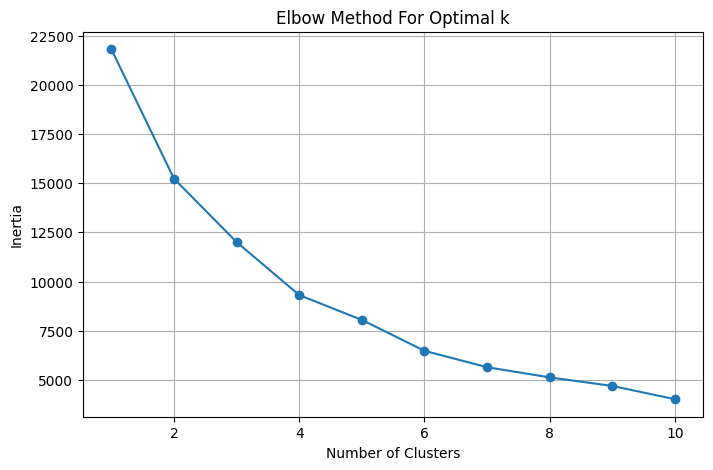

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


#### **Applying K-Means Clustering**


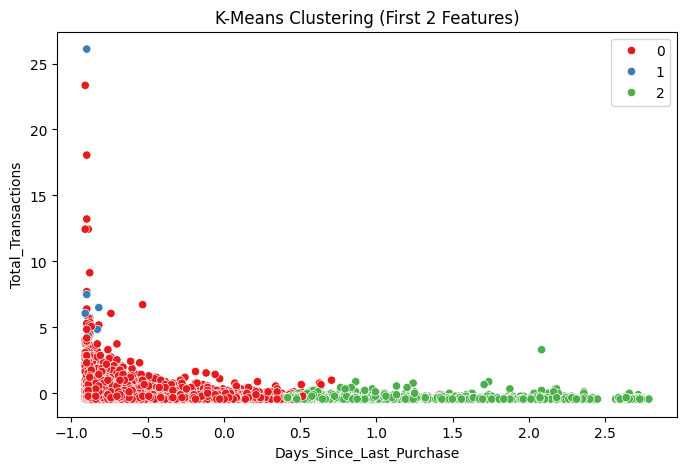

In [ ]:
# Let's assume optimal k from elbow plot is 3 (change if needed)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled_df)

# Add to original DataFrame
customer_data['KMeans_Cluster'] = kmeans_labels

# Visualize clusters using first two features
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_scaled_df.iloc[:, 0], y=X_scaled_df.iloc[:, 1], hue=kmeans_labels, palette='Set1')
plt.title('K-Means Clustering (First 2 Features)')
plt.xlabel(X_scaled_df.columns[0])
plt.ylabel(X_scaled_df.columns[1])
plt.show()


####  **Evaluating K-Means Clustering**


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled_df, kmeans_labels)
print(f"Silhouette Score for K-Means: {score:.3f}")


Silhouette Score for K-Means: 0.456


---

## **Hierarchical Clustering**

#### **Dendrogram Analysis**


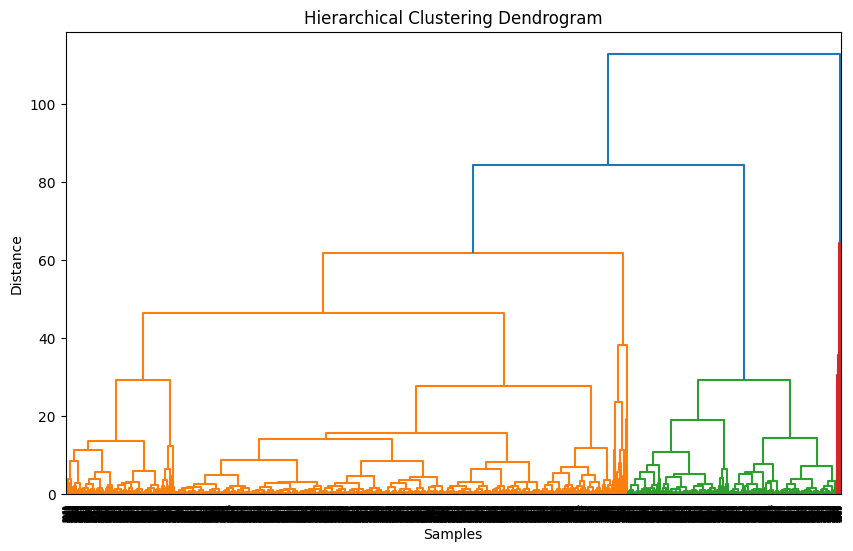

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled_df, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


#### **Applying Hierarchical Clustering**


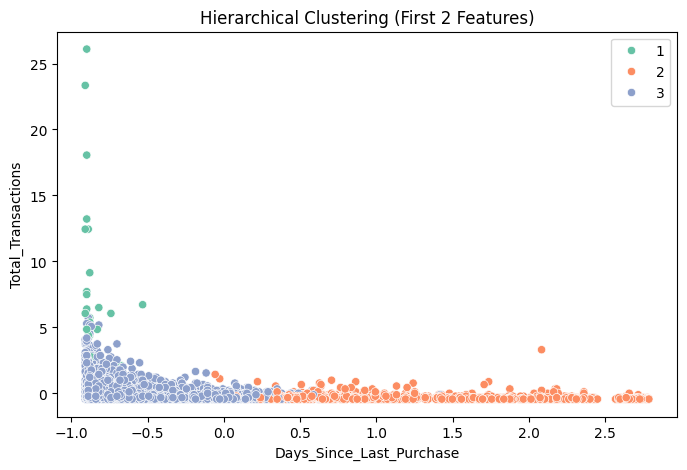

In [ ]:
from scipy.cluster.hierarchy import fcluster

# Cut dendrogram to form 3 clusters (change if needed)
hierarchical_labels = fcluster(linked, 3, criterion='maxclust')

# Add to original DataFrame
customer_data['Hierarchical_Cluster'] = hierarchical_labels

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_scaled_df.iloc[:, 0], y=X_scaled_df.iloc[:, 1], hue=hierarchical_labels, palette='Set2')
plt.title('Hierarchical Clustering (First 2 Features)')
plt.xlabel(X_scaled_df.columns[0])
plt.ylabel(X_scaled_df.columns[1])
plt.show()


## **Experiments and Results**
### ***K-Means Clustering***

- The optimal number of clusters was determined using the **Elbow Method**.
- `KMeans(n_clusters=3, random_state=42)` was applied.
- The results showed 3 distinct customer segments.

### ***Hierarchical Clustering***

- A dendrogram was plotted using the `ward` linkage method.
- Based on the visual inspection of the dendrogram, **3 clusters** were selected.
- A scatterplot of the first two features shows clear separation of clusters.

## **Bar Plot: Cluster Sizes for K-Means**

<ipython-input-70-093aa96d263a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kmeans_counts.index, y=kmeans_counts.values, palette='Set3')


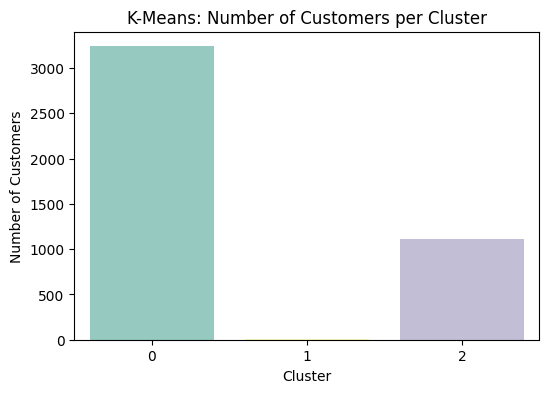

In [ ]:
# Cluster sizes for K-Means
kmeans_counts = pd.Series(kmeans.labels_).value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=kmeans_counts.index, y=kmeans_counts.values, palette='Set3')
plt.title('K-Means: Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()


## **Bar Plot: Cluster Sizes for Hierarchical Clustering**

<ipython-input-71-03f828caa067>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hier_counts.index, y=hier_counts.values, palette='Set2')


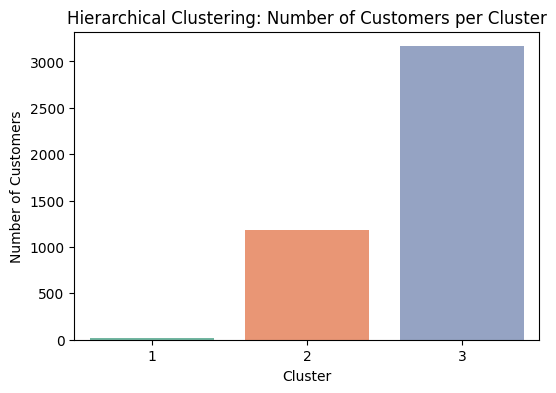

In [ ]:
# Cluster sizes for Hierarchical Clustering
hier_counts = pd.Series(hierarchical_labels).value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=hier_counts.index, y=hier_counts.values, palette='Set2')
plt.title('Hierarchical Clustering: Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()


## **Bar Plot: Mean Feature Values per Cluster (K-Means)**
#### This shows average behavior per cluster, e.g., if one group spends more or buys more often.

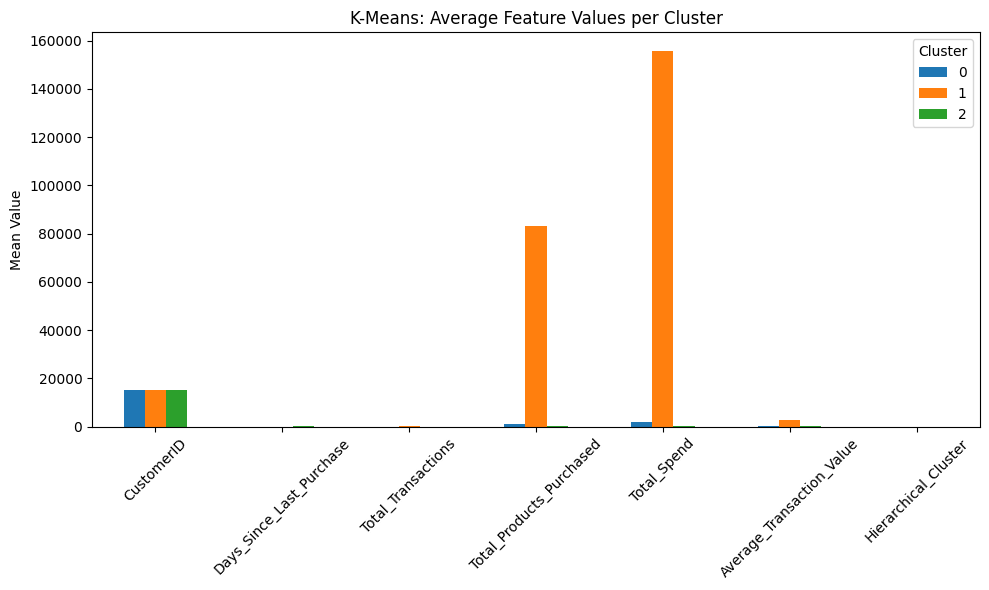

In [ ]:
# Add K-Means labels to original DataFrame if not already done
customer_data['KMeans_Cluster'] = kmeans.labels_

# Compute mean feature values per cluster
kmeans_means = customer_data.groupby('KMeans_Cluster').mean(numeric_only=True)

# Plot mean of each feature for each cluster
kmeans_means.T.plot(kind='bar', figsize=(10, 6))
plt.title('K-Means: Average Feature Values per Cluster')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## **Bar Plot: Mean Feature Values per Cluster (Hierarchical)**

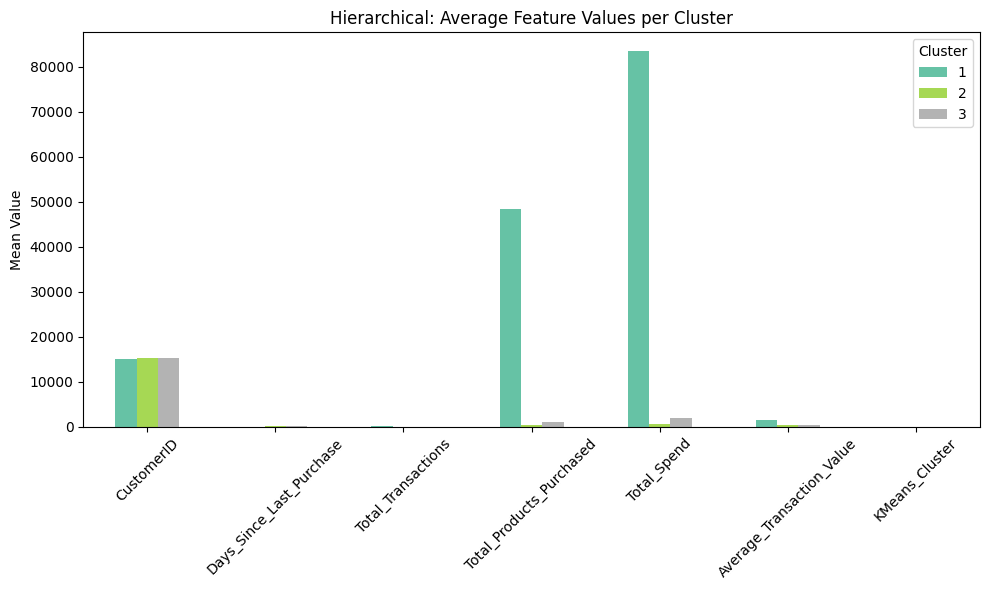

In [ ]:
# Already added: customer_data['Hierarchical_Cluster']
hier_means = customer_data.groupby('Hierarchical_Cluster').mean(numeric_only=True)

hier_means.T.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Hierarchical: Average Feature Values per Cluster')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## **Comparision of cluster sizes between K-Means and Hierarchical:**

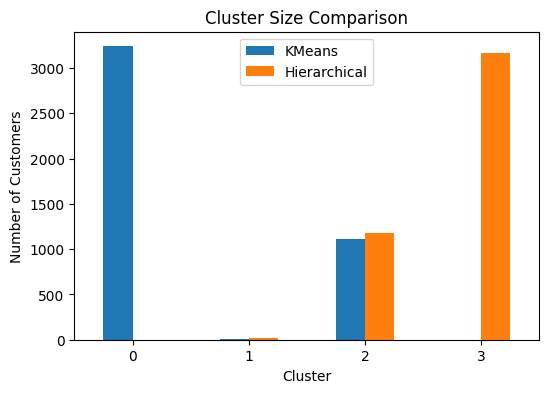

In [ ]:
comparison_df = pd.DataFrame({
    'KMeans': kmeans_counts,
    'Hierarchical': hier_counts
})

comparison_df.plot(kind='bar', figsize=(6, 4))
plt.title('Cluster Size Comparison')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()


In [ ]:
df.columns



Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Transaction_Status',
       'InvoiceDay', 'Total_Spend'],
      dtype='object')

 # **Cluster Size Comparison: K-Means vs Hierarchical**
 This bar chart compares the number of customers assigned to each cluster by two different clustering algorithms: K-Means and Hierarchical Clustering.

Each bar represents a cluster (e.g., Cluster 0, Cluster 1, etc.), and the height indicates the number of customers in that segment. The skyblue bars correspond to K-Means results, while the salmon bars correspond to Hierarchical Clustering.

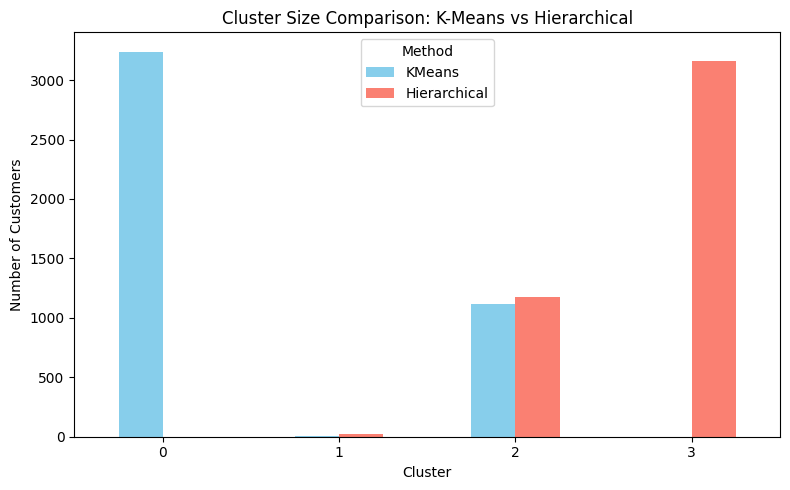

In [ ]:
comparison_df.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('Cluster Size Comparison: K-Means vs Hierarchical')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Method')
plt.tight_layout()
plt.show()
